In [ ]:
                                        # How Has Inflaction  Impacted Everyday Prices ? (2020 - 2024)
   
  # *** Objective: ***
  # Analysing the effect of infaltion on everyday consumer goods such as Food, Gas, and Housing using Python and  CPI Data.

# ** Data Source: ** U.S. Bureau of Labor Statistics / CPI Data
       #  The data is sourced from the U.S. Bureau of Labor Statistics (BLS) website (https://www.bls.gov/cpi/)

# ** tools Used: **   Python ->  Pandas, Matplotlib, Seaborn
                   #  EDI: VS Code -> Jupyter Notebook                 

# ** Author: **  Robby Deffo
# ** Completion Date: **  


In [2]:
# Importing necessary libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [6]:
                                                            ### DATA PREPARATION ###
#Loading our dataset

cali_goods_df = pd.read_csv('CPI_CA-LA....csv')
food_df = pd.read_csv('CPI_U.S-Food.csv')
gas_df = pd.read_csv('CPI_U.S-Gas.csv')
shelter_df = pd.read_csv('CPI_U.S-Shltr.csv')

# # Checking the first few rows of the dataset
# print(cali_goods_df.head())
# print(food_df.head())
# print(gas_df.head())
# print(shelter_df.head())


In [7]:
                                    ### Cleaning Our DataFrames And Removing Any Redundant Columns ###

# Selecting relevant column needed for analysis
food_df = food_df[['Year', 'Period', 'Value']].rename(columns={'Value':'Food_CPI'})
gas_df = gas_df[['Year', 'Period', 'Value']].rename(columns={'Value':'Gasoline_CPI'})
shelter_df = shelter_df[['Year', 'Period', 'Value']].rename(columns={'Value':'Shelter_CPI'})
cali_goods_df = cali_goods_df[['Year', 'Period', 'Value']].rename(columns={'Value':'Cali_CPI'})

## Creating a Date column using Year and Period Columns. (I avoid using labels columns as I may face issues if the format is not consistent)
def create_date(Year,Period ):
    months = int(Period.replace('M', ''))
    return pd.Timestamp(year=int(Year), month=months, day=1)
## Create the Date colum in each dataframe and apply the"create_date" function in each dataFrame
food_df = food_df.assign(Date=food_df.apply(lambda row: create_date(row['Year'], row['Period']), axis=1))
gas_df = gas_df.assign(Date=gas_df.apply(lambda row: create_date(row['Year'], row['Period']), axis=1))
shelter_df = shelter_df.assign(Date=shelter_df.apply(lambda row: create_date(row['Year'], row['Period']), axis=1))
cali_goods_df = cali_goods_df.assign(Date=cali_goods_df.apply(lambda row: create_date(row['Year'], row['Period']), axis=1))
## Removing the Year and Period columns as they are no longer needed
food_df = food_df.drop(columns=['Year', 'Period'])
gas_df = gas_df.drop(columns=['Year', 'Period'])
shelter_df = shelter_df.drop(columns=['Year', 'Period'])
cali_goods_df = cali_goods_df.drop(columns=['Year', 'Period'])

# ## Lets see what our DataFrames look like now
# print(food_df.head())
# print(gas_df.head())
# print(shelter_df.head())
# print(cali_goods_df.head())

# Now lets merge all of our dataframes into one single dataframe using the Date column as the key
merged_df=(
    food_df.merge(gas_df, on='Date', how='outer')
    .merge(shelter_df, on='Date', how='outer')
    .merge(cali_goods_df, on='Date', how='outer'))
# Organizing by Date in ascending order 
merged_df = merged_df.sort_values(by='Date')
# Resetting the index to ensure it is sequential after sorting
merged_df = merged_df.reset_index(drop=True)
 
#  # Now lets see what the first 20 rows of our merged dataframe look like and  check if theare are any missing values  
# print(merged_df.head(20))  
# print(merged_df.isnull().sum())

# Reorganizing the column order of our merged dataframe
  # I Noticed thtat the Data colun is not the first column, hence I think it is best to move it to the first column
merged_df = merged_df[['Date', 'Food_CPI', 'Gasoline_CPI', 'Shelter_CPI', 'Cali_CPI']]
# Now lets see what the first 20 rows of our merged dataframe look like
print(merged_df.head(20))


         Date  Food_CPI  Gasoline_CPI  Shelter_CPI  Cali_CPI
0  2020-01-01   260.638       227.010      323.053   277.755
1  2020-02-01   261.487       218.373      324.254   278.657
2  2020-03-01   262.320       202.205      324.615   276.589
3  2020-04-01   266.137       168.891      324.522   275.853
4  2020-05-01   267.792       168.528      325.265   276.842
5  2020-06-01   269.051       185.422      325.814   278.121
6  2020-07-01   268.132       194.397      326.580   279.899
7  2020-08-01   268.383       194.449      326.997   280.116
8  2020-09-01   268.465       195.888      327.116   279.366
9  2020-10-01   269.169       192.792      327.273   279.947
10 2020-11-01   268.539       187.609      327.435   280.102
11 2020-12-01   269.383       193.990      327.702   279.560
12 2021-01-01   270.260       207.406      328.282   280.178
13 2021-02-01   270.672       221.689      329.005   281.347
14 2021-03-01   271.135       247.652      330.122   282.648
15 2021-04-01   272.367 

In [15]:
                                        ### Analysing Our Merged Data Frame ###

# First, Lets calculate the percentage change of each column in a new dataframe using January 2020 as the base months

df_pct_change = merged_df.copy()  # Create a copy of the merged dataframe to avoid modifying the original
baseline = df_pct_change.loc[0]
# Calculate the percentage change for each column
for column in df_pct_change.columns[1:]:
    df_pct_change[column] = ((df_pct_change[column] - baseline[column]) / baseline[column]) * 100
# Lets udpdate the column to reflect the percentage change and roun it to 2 decimal places
for column in df_pct_change.columns[1:]:
    df_pct_change[column] = df_pct_change[column].round(2)
df_pct_change = df_pct_change.rename(columns={
    'Food_CPI': 'Food_CPI % Chnge',
    'Gasoline_CPI': 'Gasoline_CPI % Chnge',
    'Shelter_CPI': 'Shelter_CPI % Chnge',
    'Cali_CPI': 'Cali_CPI % Chnge'
})
# Now lets see what the first 20 rows of our percentage change dataframe look like
print(df_pct_change.head(20))

         Date  Food_CPI % Chnge  Gasoline_CPI % Chnge  Shelter_CPI % Chnge  \
0  2020-01-01              0.00                  0.00                 0.00   
1  2020-02-01              0.33                 -3.80                 0.37   
2  2020-03-01              0.65                -10.93                 0.48   
3  2020-04-01              2.11                -25.60                 0.45   
4  2020-05-01              2.74                -25.76                 0.68   
5  2020-06-01              3.23                -18.32                 0.85   
6  2020-07-01              2.88                -14.37                 1.09   
7  2020-08-01              2.97                -14.34                 1.22   
8  2020-09-01              3.00                -13.71                 1.26   
9  2020-10-01              3.27                -15.07                 1.31   
10 2020-11-01              3.03                -17.36                 1.36   
11 2020-12-01              3.36                -14.55           

In [16]:
# Exporting the percentage change dataframe 
df_pct_change.to_csv('CPI_Percent_Change_Final.csv', index=False)

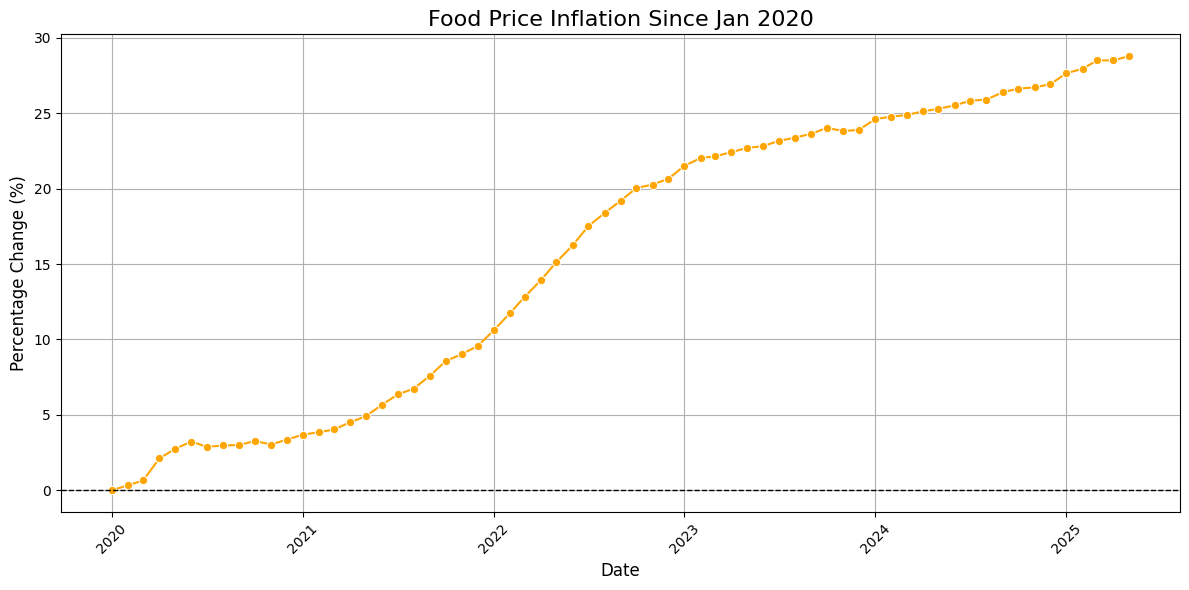

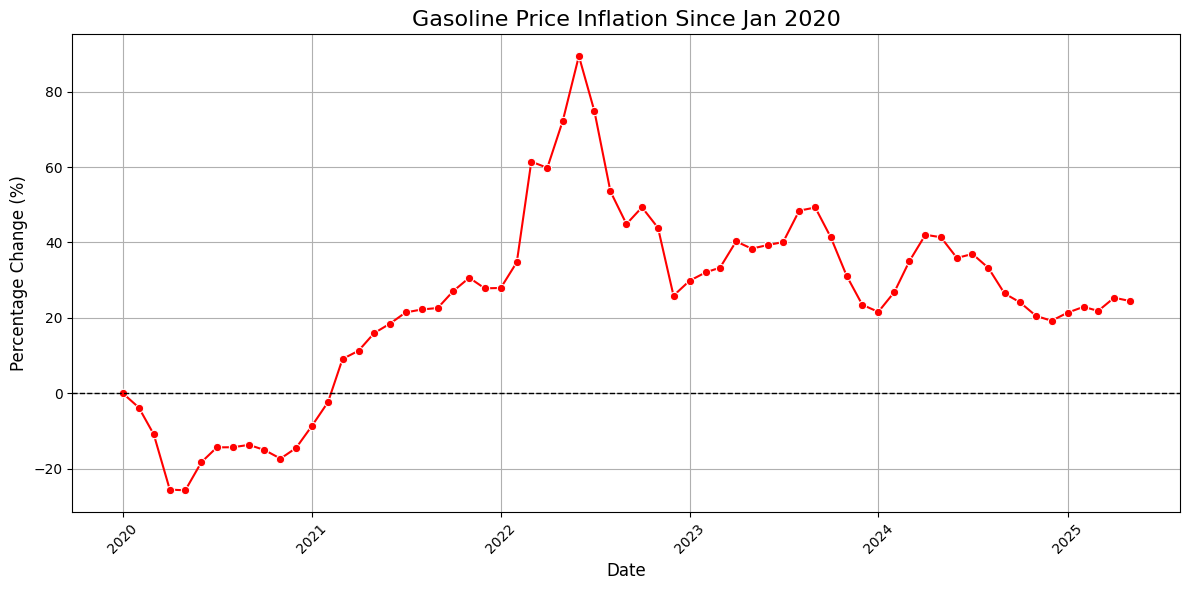

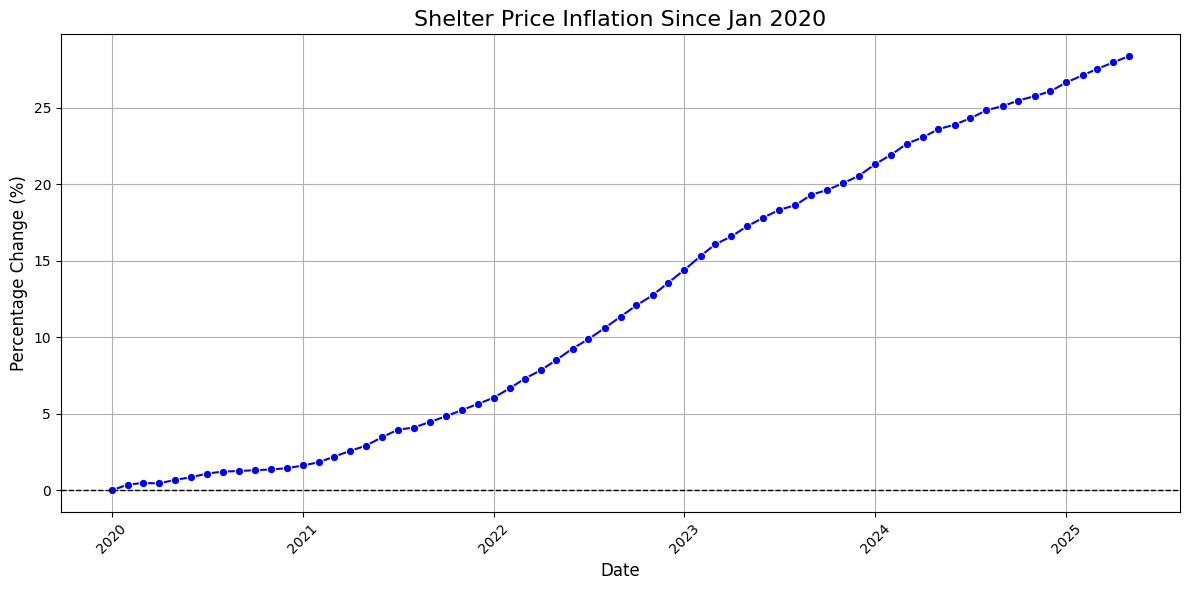

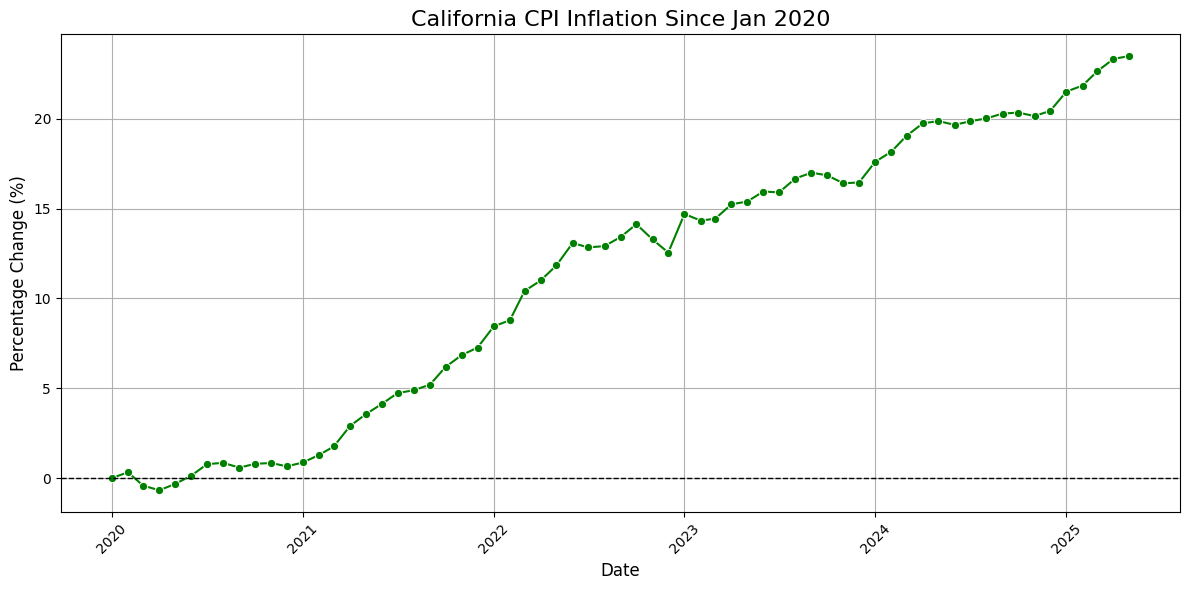

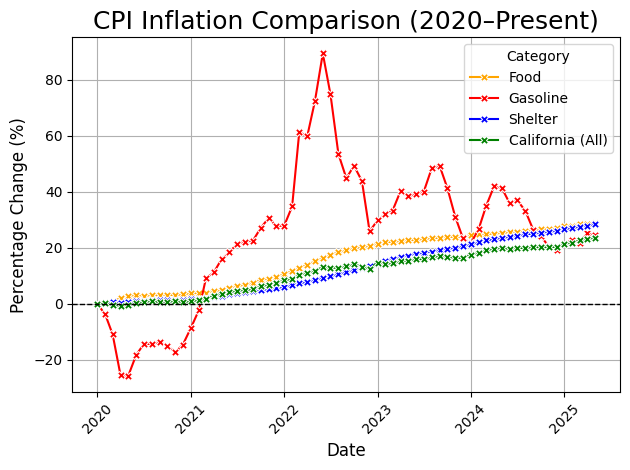

In [45]:
                                                    # Visualization


df = df_pct_change.copy()
def plot_single_cpi(df, y_col, title, color, filename=None):
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=df, x='Date', y=y_col, marker='o', color=color)
    plt.axhline(0, linestyle='--', color='black', linewidth=1)
    plt.title(title, fontsize=16)
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Percentage Change (%)', fontsize=12)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.grid(True)
    if filename:
        plt.savefig(filename, dpi=300)
    plt.show()

# Plot each chart
plot_single_cpi(df, 'Food_CPI % Chnge', 'Food Price Inflation Since Jan 2020', 'orange', 'food_cpi_chart.png')
plot_single_cpi(df, 'Gasoline_CPI % Chnge', 'Gasoline Price Inflation Since Jan 2020', 'red', 'gas_cpi_chart.png')
plot_single_cpi(df, 'Shelter_CPI % Chnge', 'Shelter Price Inflation Since Jan 2020', 'blue', 'shelter_cpi_chart.png')
plot_single_cpi(df, 'Cali_CPI % Chnge', 'California CPI Inflation Since Jan 2020', 'green', 'cali_cpi_chart.png')

# Plotting the combined chart for all categories
sns.lineplot(data=df, x='Date', y='Food_CPI % Chnge', label='Food', color='orange', marker="X")
sns.lineplot(data=df, x='Date', y='Gasoline_CPI % Chnge', label='Gasoline', color='red', marker="X")
sns.lineplot(data=df, x='Date', y='Shelter_CPI % Chnge', label='Shelter', color='blue', marker="X")
sns.lineplot(data=df, x='Date', y='Cali_CPI % Chnge', label='California (All)', color='green', marker="X")


plt.axhline(0, linestyle='--', color='black', linewidth=1)
plt.title('CPI Inflation Comparison (2020–Present)', fontsize=18)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Percentage Change (%)', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Category', fontsize=10)
plt.tight_layout()
plt.grid(True)
plt.savefig('combined_cpi_comparison_chart.png', dpi=300)
plt.show()

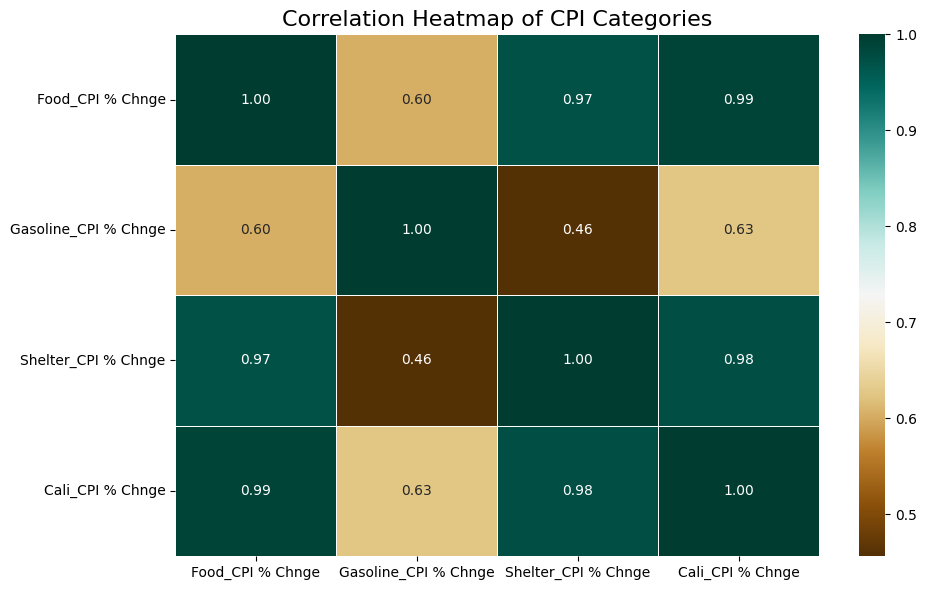

In [54]:
# Correlation 
# Lets check to see if there's any type of correlation between those CPI
correlation = df[['Food_CPI % Chnge', 'Gasoline_CPI % Chnge', 'Shelter_CPI % Chnge', 'Cali_CPI % Chnge']].corr()
plt.figure(figsize=(10, 6))
sns.heatmap(correlation, annot=True, cmap='BrBG', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of CPI Categories', fontsize=16)
plt.tight_layout()
plt.savefig('cpi_correlation_heatmap.png')
plt.show()

In [ ]:
# Which is more volatile using the standard deviation
volatility = df[['Food_CPI % Chnge', 'Gasoline_CPI % Chnge', 'Shelter_CPI % Chnge', 'Cali_CPI % Chnge']].std()
print(volatility)

Food_CPI % Chnge         9.751388
Gasoline_CPI % Chnge    24.694544
Shelter_CPI % Chnge      9.592354
Cali_CPI % Chnge         7.794242
dtype: float64
